# 03 - Sparse Autoencoder Training & Semantic Grounding

## 1. Setup and Imports
Configure paths to seamlessly run on Colab or locally, and install required libraries.

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    base_dir = '/content/drive/MyDrive/xai-project5'
else:
    base_dir = os.path.abspath(os.path.join('..', '..'))

feat_dir = os.path.join(base_dir, 'src', 'results', 'feature_extraction')
dict_dir = os.path.join(base_dir, 'src', 'results', '02_dictionary_creation')
save_dir = os.path.join(base_dir, 'src', 'results', '03_sae_training')
scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements_ai_core.txt')

os.makedirs(save_dir, exist_ok=True)

if scripts_path not in sys.path:
    sys.path.append(scripts_path)

print(f"Setup complete.\nOutput directory: {save_dir}")


Setup complete.
Output directory: /home/emmanuelmessina00/Scrivania/xai-project5/src/results/03_sae_training


In [ ]:
!pip install -q -r "{req_path}" transformers pillow matplotlib seaborn


In [2]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoProcessor, AutoModel
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sae import SparseAutoencoder, sae_loss_function

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Sparse Autoencoder Training

**Sparse Autoencoders (SAEs)** implement a form of *sparse dictionary learning*, aiming to learn a sparse decomposition of a signal into an overcomplete dictionary of atoms.

Given an embedding $v \in \mathbb{R}^d$, the SAE decomposes the vector into:
- **Activation vector**: $\phi(v) := \sigma(W_{enc}^{\top}(v - b))$
- **Reconstructed vector**: $\hat{v} := W_{dec}^{\top}\phi(v) + b$

The loss function combines a **reconstruction objective** with a **sparsity regularization**:
$$\mathcal{L}(v) = R(v) + \lambda S(v)$$
where $R(v) = \|v - \hat{v}\|_2^2$ (L2 Loss) and $S(v) = \|\phi(v)\|_1$ (L1 Loss).

In [4]:
embeddings_path = os.path.join(feat_dir, 'biomedclip_openi_with_reports.pt')
print(f"Caricamento dataset visivo da: {embeddings_path}")

# Carichiamo il file .pt
data = torch.load(embeddings_path, map_location=device)

# Estraiamo il tensore puro dal dizionario salvato nel Notebook 1
if isinstance(data, dict) and 'embeddings' in data:
    vision_embeddings = data['embeddings']
else:
    vision_embeddings = data # Fallback se è già un tensore

# Assicuriamoci che i dati siano in formato float32
vision_embeddings = vision_embeddings.to(torch.float32)

BATCH_SIZE = 256
dataset = TensorDataset(vision_embeddings)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

INPUT_DIM = vision_embeddings.shape[1]
HIDDEN_DIM = 2048
LR = 1e-3
L1_LAMBDA = 1e-4
EPOCHS = 20

sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
optimizer = optim.Adam(sae.parameters(), lr=LR)
print(f"Dataset caricato: {vision_embeddings.shape[0]} immagini. SAE inizializzato con successo!")

Caricamento dataset visivo da: /home/emmanuelmessina00/Scrivania/xai-project5/src/results/feature_extraction/biomedclip_openi_with_reports.pt
Dataset caricato: 3666 immagini. SAE inizializzato con successo!


In [5]:
checkpoint_path = os.path.join(save_dir, 'sae_checkpoint.pt')
start_epoch = 0
history = {'total': [], 'mse': [], 'l1': []}

# Resume from checkpoint if interrupted
if os.path.exists(checkpoint_path):
    print("Found training checkpoint! Resuming...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    sae.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    print(f"Resuming from epoch {start_epoch + 1}...")

print("\n--- STARTING SAE TRAINING ---")
for epoch in range(start_epoch, EPOCHS):
    sae.train()
    epoch_total_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_l1_loss = 0.0

    for batch in dataloader:
        x = batch[0].to(device)
        
        # Forward pass
        x_hat, z = sae(x)
        
        # Calculate loss
        total_loss, mse_loss, l1_loss = sae_loss_function(x, x_hat, z, L1_LAMBDA)
        
        # Backward and optimize
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Normalize decoder weights to prevent collapse (force norm=1)
        sae.normalize_decoder_weights()

        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_l1_loss += l1_loss.item()
    
    avg_total_loss = epoch_total_loss / len(dataloader)
    avg_mse = epoch_mse_loss / len(dataloader)
    avg_l1 = epoch_l1_loss / len(dataloader)
    
    history['total'].append(avg_total_loss)
    history['mse'].append(avg_mse)
    history['l1'].append(avg_l1)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Total Loss: {avg_total_loss:.4e} | "
          f"MSE (Reconstruction): {avg_mse:.4e} | "
          f"L1 (Sparsity): {avg_l1:.4e}")
          
    # Save checkpoint at the end of each epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': sae.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history
    }, checkpoint_path)

# Save final model properly for Notebook 04
final_model_path = os.path.join(save_dir, 'sae_model_final.pt')
torch.save(sae.state_dict(), final_model_path)
print(f"\nTraining complete! Final model saved to: {final_model_path}")



--- STARTING SAE TRAINING ---
Epoch [01/20] | Total Loss: 1.4418e-03 | MSE (Reconstruction): 1.4412e-03 | L1 (Sparsity): 5.7923e-03
Epoch [02/20] | Total Loss: 2.5028e-04 | MSE (Reconstruction): 2.4990e-04 | L1 (Sparsity): 3.8088e-03
Epoch [03/20] | Total Loss: 1.6611e-04 | MSE (Reconstruction): 1.6575e-04 | L1 (Sparsity): 3.5297e-03
Epoch [04/20] | Total Loss: 1.1631e-04 | MSE (Reconstruction): 1.1594e-04 | L1 (Sparsity): 3.7407e-03
Epoch [05/20] | Total Loss: 8.3745e-05 | MSE (Reconstruction): 8.3325e-05 | L1 (Sparsity): 4.1992e-03
Epoch [06/20] | Total Loss: 6.4473e-05 | MSE (Reconstruction): 6.4012e-05 | L1 (Sparsity): 4.6075e-03
Epoch [07/20] | Total Loss: 5.3150e-05 | MSE (Reconstruction): 5.2664e-05 | L1 (Sparsity): 4.8559e-03
Epoch [08/20] | Total Loss: 4.5349e-05 | MSE (Reconstruction): 4.4845e-05 | L1 (Sparsity): 5.0407e-03
Epoch [09/20] | Total Loss: 3.9837e-05 | MSE (Reconstruction): 3.9319e-05 | L1 (Sparsity): 5.1791e-03
Epoch [10/20] | Total Loss: 3.5542e-05 | MSE (Recon

## 3. Training Data Analysis
Let's visualize the training metrics to ensure the SAE converged properly and correctly balanced the trade-off between Reconstruction (MSE) and Sparsity (L1).

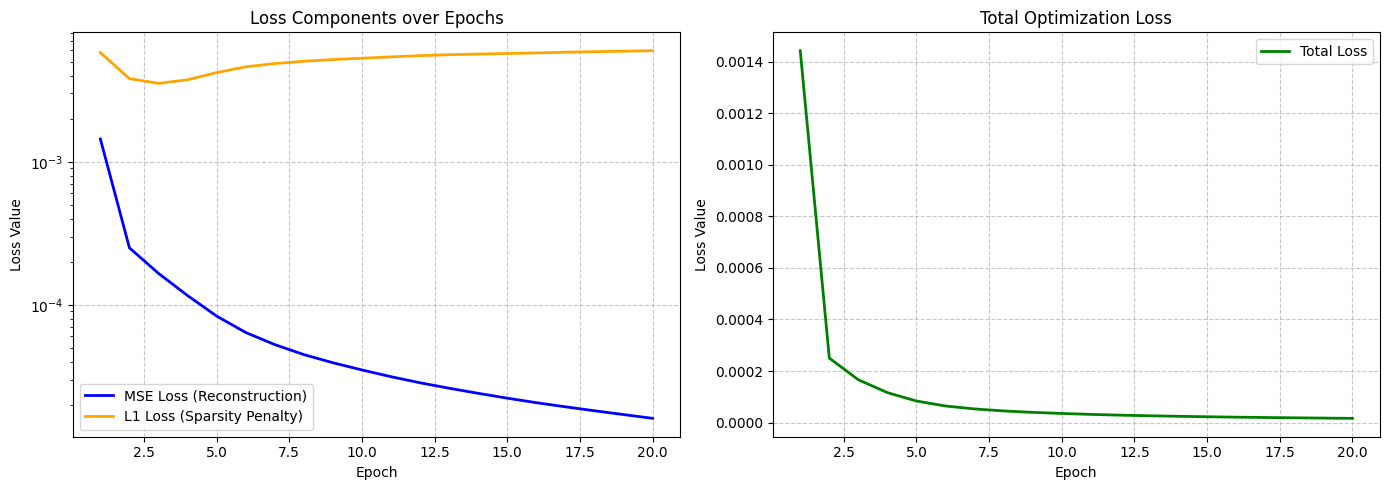

In [6]:
epochs_range = range(1, len(history['total']) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Reconstruction vs Sparsity Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['mse'], label='MSE Loss (Reconstruction)', color='blue', linewidth=2)
plt.plot(epochs_range, history['l1'], label='L1 Loss (Sparsity Penalty)', color='orange', linewidth=2)
plt.title('Loss Components over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Log scale for better visibility if differences are huge
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Total Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['total'], label='Total Loss', color='green', linewidth=2)
plt.title('Total Optimization Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()


## 4. Global Explainability: Semantic Grounding

Global explainability aims to map and understand the model's internal architecture in its entirety, independently of individual input samples. In this paradigm, the goal is to build a dictionary that connects the latent visual concepts—learned in a totally unsupervised manner—to human language.

This process, known as *semantic grounding*, is achieved by computing the cosine similarity between the textual embeddings of known clinical concepts (from Notebook 02) and the decoder dictionary learned by the Sparse Autoencoder.

Since both vectors are subjected to L2 normalization, calculating the cosine similarity elegantly reduces to a single matrix multiplication: $S = T \cdot W_{dec}$, where $T$ represents the text embeddings matrix and $W_{dec}$ is the SAE decoder dictionary. This geometric operation allows us to establish the "at-rest" alignment of the network, assigning the most strongly connected latent neuron to each medical phrase.

In [7]:
dict_path = os.path.join(dict_dir, 'biomedclip_medical_dictionary_embeddings.pt')
print(f"Loading Medical Dictionary from: {dict_path}")

dictionary_data = torch.load(dict_path, map_location=device)
medical_concepts = list(dictionary_data.keys())
tensors_list = list(dictionary_data.values())

# Concateniamo i tensori in una singola matrice T
T_matrix = torch.stack(tensors_list).to(device)

# Rimuoviamo eventuali dimensioni extra (se la shape è [N, 1, 512] la facciamo diventare [N, 512])
if T_matrix.dim() == 3:
    T_matrix = T_matrix.squeeze(1)

print(f"Caricati {len(medical_concepts)} concetti clinici semantici.")
print(f"Shape della Matrice T: {T_matrix.shape}")

# Compute Cosine Similarity
with torch.no_grad():
    sae_dictionary = F.normalize(sae.decoder.weight.data, p=2, dim=0)

similarities = torch.matmul(T_matrix, sae_dictionary)

top_k = 3
# We'll print just a sample (first 5 concepts) to avoid cluttering the output
sample_size = min(5, len(medical_concepts))
print(f"\nShowing Grounding for the first {sample_size} concepts:\n")

for idx in range(sample_size):
    concept = medical_concepts[idx]
    concept_sims = similarities[idx]
    
    # Get top K values and their indices (the SAE "neurons")
    top_values, top_indices = torch.topk(concept_sims, top_k)
    
    print(f"Textual Concept: '{concept}'")
    for i in range(top_k):
        print(f"  -> SAE Neuron {top_indices[i].item():4d} (Similarity: {top_values[i].item():.4f})")
    print("-" * 40)


Loading Medical Dictionary from: /home/emmanuelmessina00/Scrivania/xai-project5/src/results/02_dictionary_creation/biomedclip_medical_dictionary_embeddings.pt
Caricati 14 concetti clinici semantici.
Shape della Matrice T: torch.Size([14, 512])

Showing Grounding for the first 5 concepts:

Textual Concept: 'abdomen'
  -> SAE Neuron 1690 (Similarity: 0.1704)
  -> SAE Neuron 1586 (Similarity: 0.1479)
  -> SAE Neuron  568 (Similarity: 0.1442)
----------------------------------------
Textual Concept: 'adipose tissue'
  -> SAE Neuron  575 (Similarity: 0.1783)
  -> SAE Neuron  794 (Similarity: 0.1508)
  -> SAE Neuron  808 (Similarity: 0.1421)
----------------------------------------
Textual Concept: 'airspace disease'
  -> SAE Neuron  185 (Similarity: 0.1580)
  -> SAE Neuron 1690 (Similarity: 0.1485)
  -> SAE Neuron 1796 (Similarity: 0.1480)
----------------------------------------
Textual Concept: 'aorta'
  -> SAE Neuron 1017 (Similarity: 0.1612)
  -> SAE Neuron 1690 (Similarity: 0.1497)
  -

## 5. Local Explainability: Dissecting a Single Clinical Case

While global explainability defines the network's vocabulary, local explainability investigates its dynamic behavior when faced with a specific input sample (e.g., a single patient's chest X-ray).

### Translating Activations into Diagnosis
When a raw X-ray image is processed by BioMedCLIP and forwarded through the SAE, the network responds by firing a highly sparse activation vector $z$. 
1. The script captures the top most intensely fired neurons.
2. It queries the global similarity matrix $S$ to find the medical label closest to those active channels.
3. It outputs a human-readable explanation, pinpointing exactly what visual pathologies the AI detected in that specific image, converting abstract dimensions into transparent, clinical insights.

In [10]:
import open_clip

def explain_single_image(path, vlm_model, preprocess, sae_model, concept_similarities, concept_names, device, top_k_neurons=5):
    vlm_model.eval()
    sae_model.eval()
    
    # Using a dummy image if path doesn't exist just for demonstration purposes
    if not os.path.exists(path):
        print(f"Image not found at {path}. Using a blank dummy image to test logic.")
        import numpy as np
        image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    else:
        image = Image.open(path)

    if image.mode != "RGB":
        image = image.convert("RGB")

    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # Estraiamo l'embedding dell'immagine con open_clip
        vision_features = vlm_model.encode_image(image_input)
        
        # Normalizzazione L2 obbligatoria
        vision_embeddings = F.normalize(vision_features, p=2, dim=1)

        # Passaggio nel Sparse Autoencoder
        _, z = sae_model(vision_embeddings)

    activations = z[0] # Extracting the activation vector
    top_activation_values, top_neuron_indices = torch.topk(activations, top_k_neurons)

    found_concepts = False
    for val, neuron_idx in zip(top_activation_values, top_neuron_indices):
        if val.item() <= 0.05:
            continue 
            
        found_concepts = True
        print(f"\n[Neuron {neuron_idx.item():4d}] -> Activation Intensity: {val.item():.4f}")
        neuron_concept_scores = concept_similarities[:, neuron_idx]
        
        best_concept_idx = torch.argmax(neuron_concept_scores).item()
        best_concept_score = neuron_concept_scores[best_concept_idx].item()
        
        print(f"  Top Semantic Concept: '{concept_names[best_concept_idx]}'")
        print(f"  Grounding Score: {best_concept_score:.4f}")

    if not found_concepts:
        print("\nNo sufficient strong activations found for this image.")


# We load the VLM processor and model specifically for the local explanation test
print("Caricamento di BioMedCLIP per l'Explainability Locale...")
model_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
vlm_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
vlm_model = vlm_model.to(device)

image_test_path = os.path.join(base_dir, 'src', 'images', 'raggi_x.jpg')
print(f"\nAnalisi immagine: {image_test_path}")

explain_single_image(
    path=image_test_path, 
    vlm_model=vlm_model, 
    preprocess=preprocess, 
    sae_model=sae, 
    concept_similarities=similarities, 
    concept_names=medical_concepts, 
    device=device
)

Caricamento di BioMedCLIP per l'Explainability Locale...

Analisi immagine: /home/emmanuelmessina00/Scrivania/xai-project5/src/images/raggi_x.jpg

[Neuron  683] -> Activation Intensity: 0.1785
  Top Semantic Concept: 'breast implants'
  Grounding Score: 0.0748

[Neuron 1337] -> Activation Intensity: 0.1777
  Top Semantic Concept: 'abdomen'
  Grounding Score: 0.1270

[Neuron   63] -> Activation Intensity: 0.1770
  Top Semantic Concept: 'bone diseases'
  Grounding Score: 0.0631

[Neuron 1364] -> Activation Intensity: 0.1371
  Top Semantic Concept: 'airspace disease'
  Grounding Score: 0.1101

[Neuron 1907] -> Activation Intensity: 0.1313
  Top Semantic Concept: 'aorta'
  Grounding Score: 0.0406
